# 📊 Sales Prediction Using Python

## Objective

The objective of this project is to develop a machine learning model that predicts product sales based on advertising expenditure across different media channels such as TV, Radio, and Newspaper.

The project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, evaluation, and interpretation.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../dataset/Advertising.csv")

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.shape

(200, 4)

In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

### Observation

- The dataset contains advertising expenditure across three media channels.
- The target variable is **Sales**.
- There are no missing values in the dataset.
- The numerical features are suitable for regression analysis.

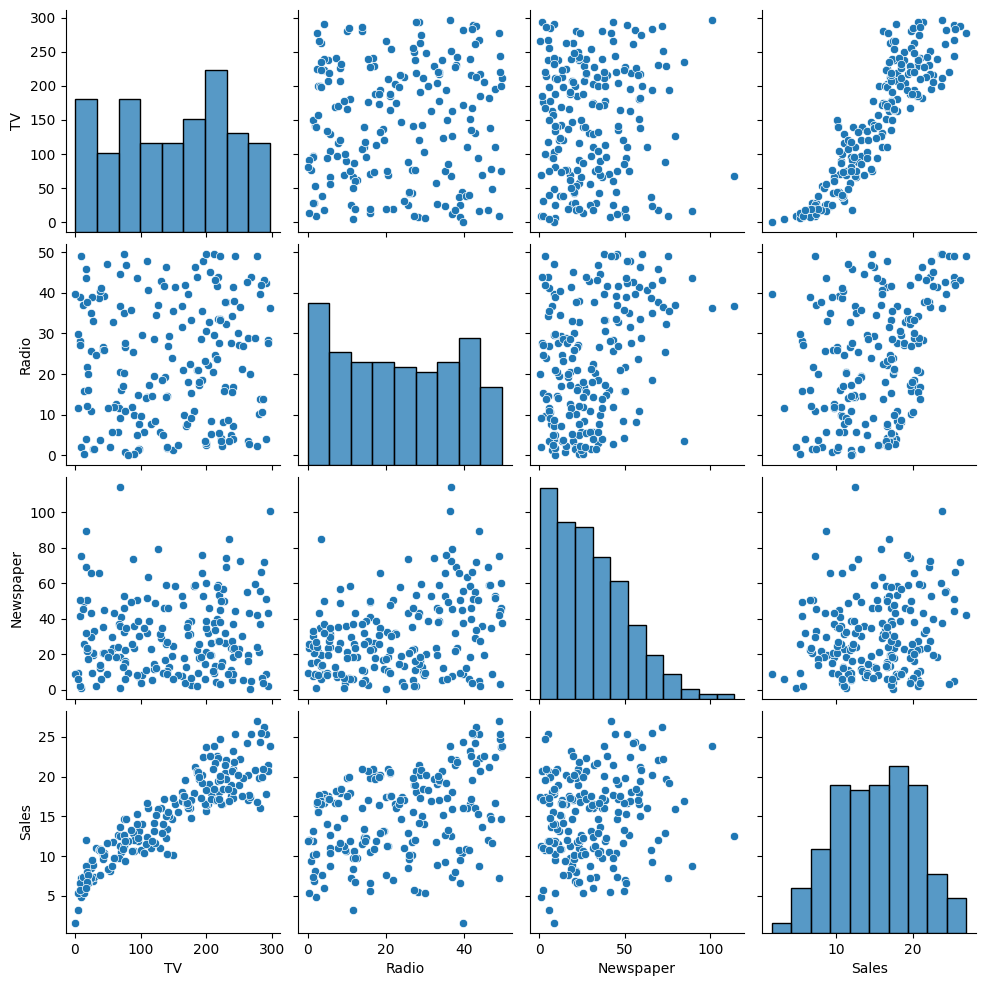

In [9]:
sns.pairplot(df)

plt.savefig(
    "../images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The pairplot shows the relationship between all numerical variables in the dataset.

- TV advertising appears to have a strong positive relationship with Sales.
- Radio advertising also shows a positive relationship with Sales.
- Newspaper advertising has a weaker relationship with Sales compared to TV and Radio.

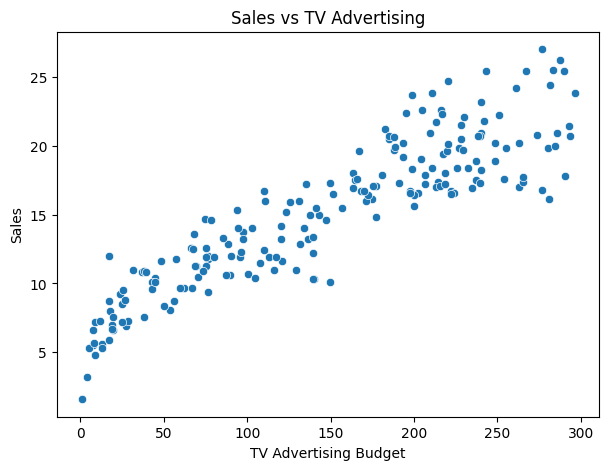

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.savefig(
    "../images/sales_vs_tv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Sales generally increase as TV advertising expenditure increases, indicating a strong positive correlation.

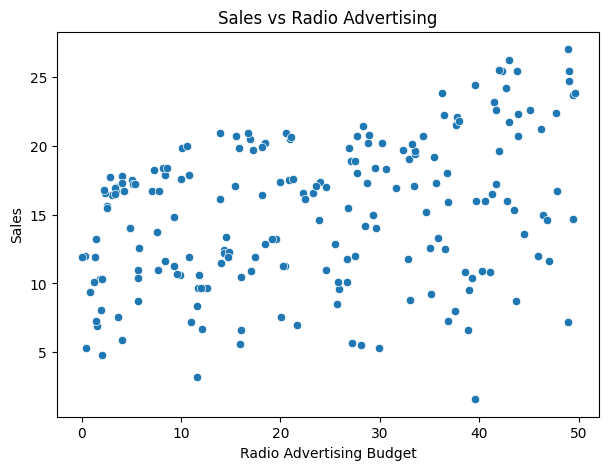

In [11]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.savefig(
    "../images/sales_vs_radio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Radio advertising also demonstrates a positive relationship with Sales, although it is slightly more scattered than TV advertising.

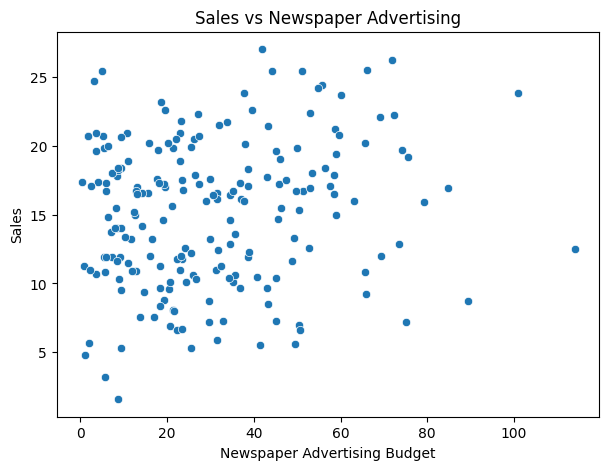

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.savefig(
    "../images/sales_vs_newspaper.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The relationship between Newspaper advertising and Sales appears relatively weak compared to TV and Radio advertising.

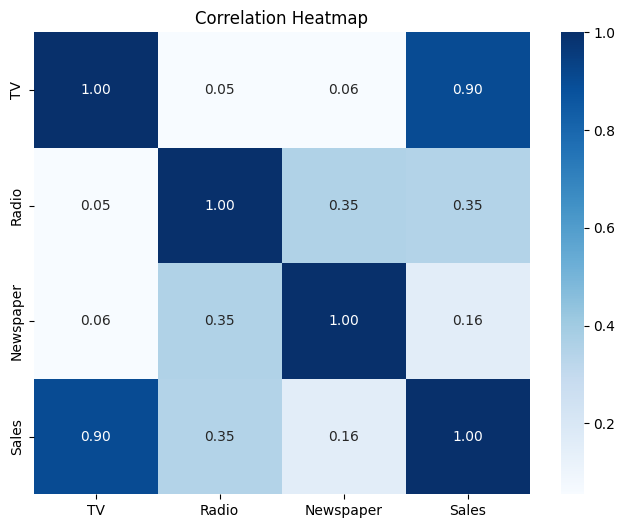

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The heatmap indicates that:

- TV has the strongest positive correlation with Sales.
- Radio also has a significant positive correlation.
- Newspaper has the weakest correlation with Sales.

In [14]:
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

In [15]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 160
Testing Samples: 40


In [17]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
linear_predictions = linear_model.predict(X_test)

In [19]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("-" * 40)
print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.2f}")

Linear Regression Performance
----------------------------------------
MAE  : 1.27
RMSE : 1.71
R²   : 0.91


In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
rf_predictions = rf_model.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-" * 40)
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.2f}")

Random Forest Performance
----------------------------------------
MAE  : 0.92
RMSE : 1.20
R²   : 0.95


In [23]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R² Score": [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.274826,1.705215,0.905901
1,Random Forest,0.918000,1.198930,0.953483


In [24]:
if rf_r2 > linear_r2:
    best_model = rf_model
    best_predictions = rf_predictions
    best_model_name = "Random Forest Regressor"
else:
    best_model = linear_model
    best_predictions = linear_predictions
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest Regressor


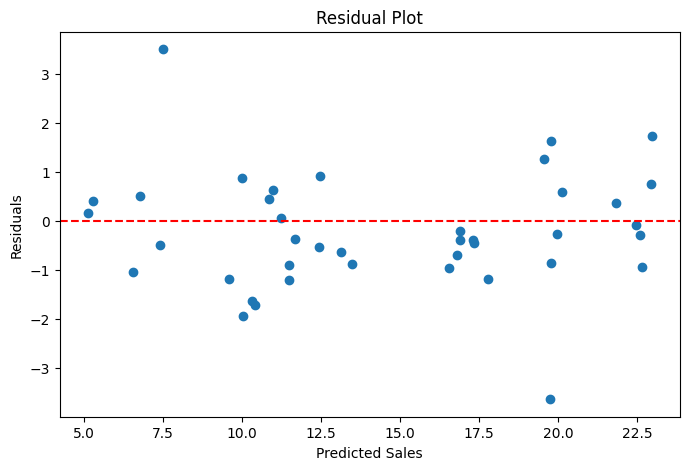

In [25]:
residuals = y_test - best_predictions

plt.figure(figsize=(8,5))

plt.scatter(best_predictions, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig(
    "../images/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The residual plot helps evaluate the prediction errors of the model.

- A random distribution of residuals around zero indicates a well-fitted model.
- Any noticeable pattern may suggest that the model is not capturing all relationships in the data.

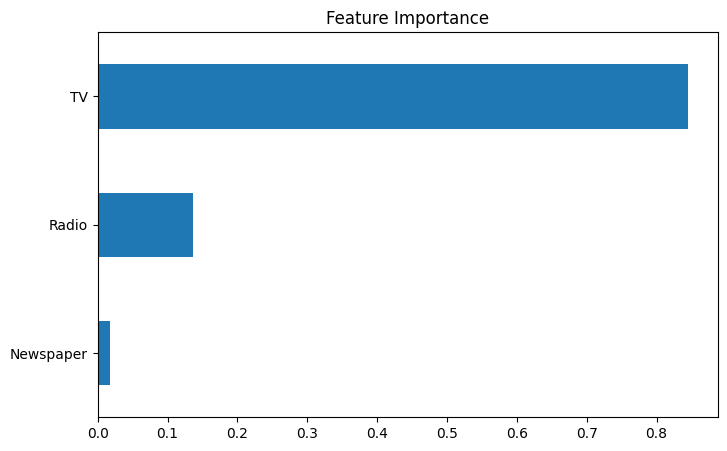

In [26]:
if best_model_name == "Random Forest Regressor":

    importance = pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    )

    importance.sort_values().plot(
        kind="barh",
        figsize=(8,5)
    )

    plt.title("Feature Importance")

    plt.savefig(
        "../images/feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [28]:
joblib.dump(best_model, "../models/sales_prediction_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


## Interpretation

The advertising channel with the greatest influence on product sales was identified using the feature importance (or coefficients) of the best-performing model.

- **TV advertising** has the strongest positive impact on sales.
- **Radio advertising** also contributes significantly to sales.
- **Newspaper advertising** has the least influence on sales compared to TV and Radio.

These findings suggest that allocating a larger portion of the advertising budget to TV and Radio campaigns may result in better sales performance.